In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from heston.closed import heston_closed_price
from heston.tree import HestonTreeFast
from black_scholes.closed import implied_volatility

from neural_network.losses import heston_residual

from neural_network.payoff import Call, Put
from neural_network.config import ModelConfig, HestonParams
from neural_network.trainer import HestonTrainer

/Users/jameswu/Documents/Imperial/Year 4/M4R/M4R_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
exercise_type = 'american'
option_type = 'put'
payoff = Put() if option_type == 'put' else Call()

In [3]:
S0 = 1.0   # Initial stock price
K = 1.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma = 0.3  # Volatility of variance
rho = -0.7   # Correlation
v0 = 0.04    # Initial variance

## Neural network vs Tree

In [4]:
S_max = 3 * S0
V_max = 0.2

params = HestonParams(
    S0=S0, v0=v0, r=r, kappa=kappa, theta=theta, sigma=sigma, rho=rho, T=T, K=K,
    S_max=S_max, V_max=V_max
)

model_config = ModelConfig(
    input_size=3,
    hidden_sizes=[64, 128, 64],
    output_size=1,
    activation=nn.ReLU(),
    learning_rate=1e-3
)


heston_trainer = HestonTrainer(model_config=model_config, heston_params=params, payoff=payoff,
                               exercise_type=exercise_type, seed=42)
optimal_weights = heston_trainer.optimise_loss_weights(
    batch_size=1000, n_trials=30, epochs_per_trial=300
)
heston_trainer.set_loss_weights(optimal_weights)


[I 2026-03-04 16:42:48,801] A new study created in memory with name: no-name-a80af0ff-e620-4d71-b495-08577141bc49
Best trial: 0. Best value: 0.0112322:   3%|▎         | 1/30 [00:03<01:48,  3.73s/it]

[I 2026-03-04 16:42:52,539] Trial 0 finished with value: 0.011232238356024027 and parameters: {'pde': 15.880351951045467, 'payoff': 98.71119356323534, 'S_min': 7.625574492082743, 'S_max': 0.017428007199285167, 'V_min': 7.706402406315087, 'V_max': 0.09039413636764165}. Best is trial 0 with value: 0.011232238356024027.


Best trial: 1. Best value: 0.000298535:   7%|▋         | 2/30 [00:07<01:44,  3.72s/it]

[I 2026-03-04 16:42:56,260] Trial 1 finished with value: 0.0002985348612128291 and parameters: {'pde': 2.210728195616282, 'payoff': 2.7504723340500967, 'S_min': 0.16028886549523721, 'S_max': 5.180682650003684, 'V_min': 0.0014669115528775077, 'V_max': 0.6708893475990442}. Best is trial 1 with value: 0.0002985348612128291.


Best trial: 2. Best value: 5.16851e-05:  10%|█         | 3/30 [00:11<01:41,  3.75s/it]

...

[I 2026-03-04 16:44:05,279] Trial 27 pruned. 


Best trial: 17. Best value: 1.83826e-05:  97%|█████████▋| 29/30 [01:17<00:02,  2.29s/it]

[I 2026-03-04 16:44:06,581] Trial 28 pruned. 


Best trial: 17. Best value: 1.83826e-05: 100%|██████████| 30/30 [01:19<00:00,  2.64s/it]

[I 2026-03-04 16:44:07,883] Trial 29 pruned. 


In [5]:
heston_trainer.train(batch_size=1024, epochs=10000, tol=1e-8)

Iteration 0, Loss: 0.34843704104423523
Iteration 100, Loss: 0.0005370253347791731
Iteration 200, Loss: 0.000125777893117629
Iteration 300, Loss: 7.939703937154263e-05
Iteration 400, Loss: 5.123554001329467e-05
Iteration 500, Loss: 4.4267701014177874e-05
Iteration 600, Loss: 3.993477366748266e-05
Iteration 700, Loss: 3.4083677746821195e-05
Iteration 800, Loss: 3.576077506295405e-05
Iteration 900, Loss: 3.2199906854657456e-05
Iteration 1000, Loss: 2.84822381217964e-05
Iteration 1100, Loss: 2.8928481697221287e-05
Iteration 1200, Loss: 2.731802851485554e-05
Iteration 1300, Loss: 2.633566691656597e-05
Iteration 1400, Loss: 2.40474382735556e-05
Iteration 1500, Loss: 2.0536439478746615e-05
Iteration 1600, Loss: 2.3033317120280117e-05
Iteration 1700, Loss: 2.2051683117751963e-05
Early stopping at epoch 1700


In [6]:
# heston_trainer.plot_losses_detailed(start_epoch=100)

In [7]:
# Heston Tree
n = 100
mv = 3 * n
mz = 6 * n
tree = HestonTreeFast(n=100, mz=mz, mv=mv, K=K, T=T, r=r, kappa=kappa, theta=theta, sigma=sigma, rho=rho)
tree.build_tree(0.01, V_max, 0.01, S_max, option_type=option_type, exercise_type=exercise_type)

In [8]:
# grid resolution
num_S = 80
num_V = 80

Ss = np.linspace(0.01, S_max, num_S)
Vs = np.linspace(0.01, V_max, num_V)
t = 0

nn_prices = np.zeros((num_V, num_S))
ht_prices = np.zeros((num_V, num_S))

for i, v_val in enumerate(Vs):
    for j, s_val in enumerate(Ss):
        nn_prices[i, j] = heston_trainer.predict(t, s_val, v_val).item()
        ht_prices[i, j] = tree.price(v_val, s_val, int(t * n - 0.5))

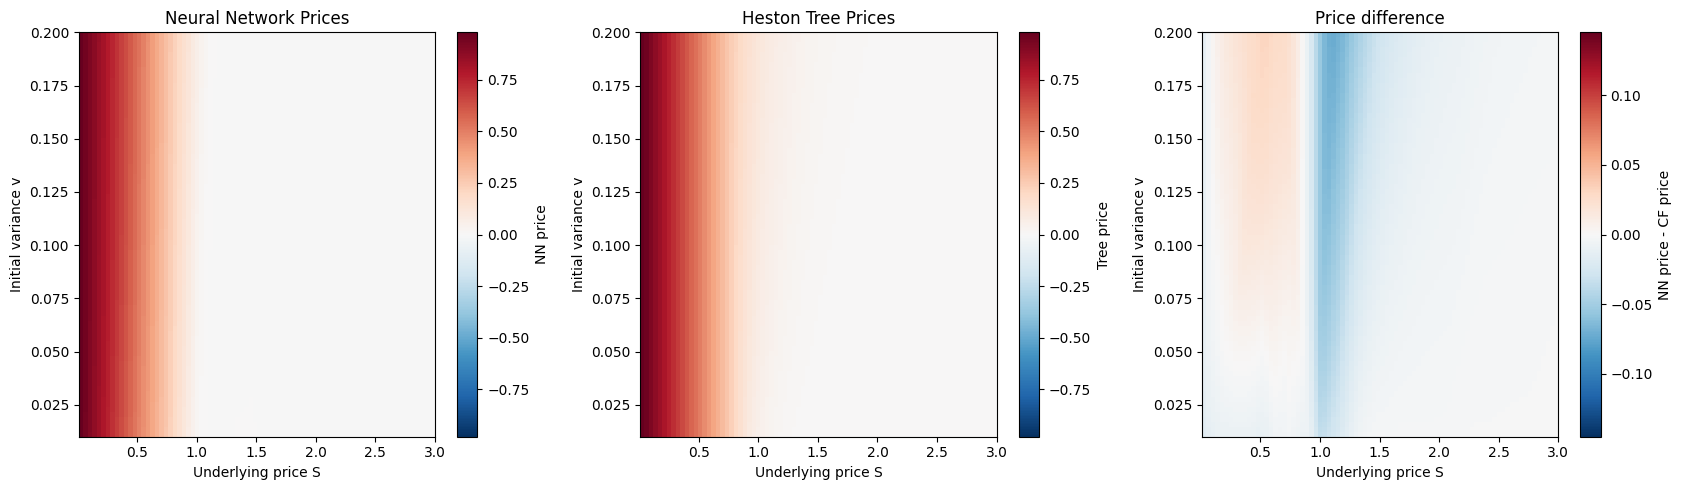

In [9]:
plt.figure(figsize=(17, 5))

plt.subplot(1, 3, 1)
vmax = np.abs(nn_prices).max()
vmin = -vmax
im = plt.imshow(nn_prices, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='NN price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Neural Network Prices')

plt.subplot(1, 3, 2)
im2 = plt.imshow(ht_prices, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im2, label='Tree price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Heston Tree Prices')

plt.subplot(1, 3, 3)
diff = nn_prices - ht_prices
# diff = (nn_prices - ht_prices) / np.maximum(np.abs(ht_prices), 1e-4)  # Relative difference, avoid division by zero
# max_rel = 0.3
# diff = np.clip(diff, -max_rel, max_rel)  # Clip extreme values for better visualization
vmax = np.abs(diff).max()*2
vmin = -vmax
im3 = plt.imshow(diff, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im3, label='NN price - CF price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Price difference')
plt.tight_layout()
plt.show()

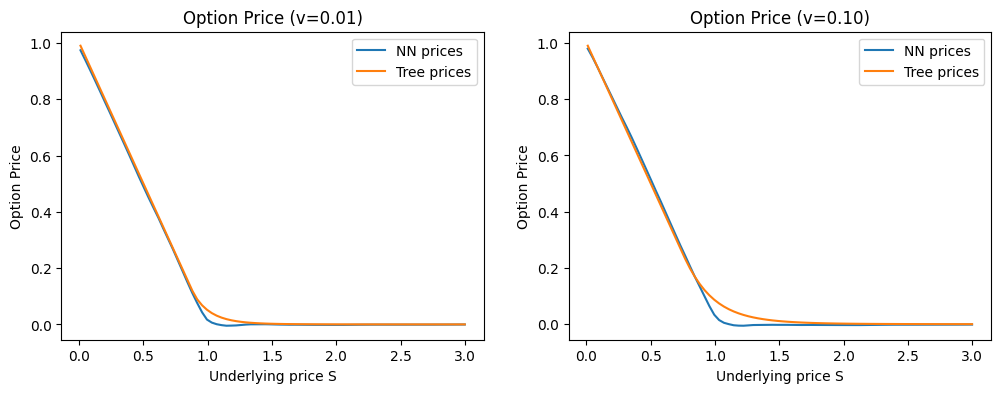

In [10]:

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
v_ind = 0
plt.plot(Ss, nn_prices[v_ind, :], label='NN prices')
plt.plot(Ss, ht_prices[v_ind, :], label='Tree prices')
plt.xlabel('Underlying price S')
plt.ylabel('Option Price')
plt.title(f'Option Price (v={Vs[v_ind]:.2f})')
plt.legend()

plt.subplot(1, 2, 2)
v_ind = 37
plt.plot(Ss, nn_prices[v_ind, :], label='NN prices')
plt.plot(Ss, ht_prices[v_ind, :], label='Tree prices')
plt.xlabel('Underlying price S')
plt.ylabel('Option Price')
plt.title(f'Option Price (v={Vs[v_ind]:.2f})')
plt.legend()

plt.show()

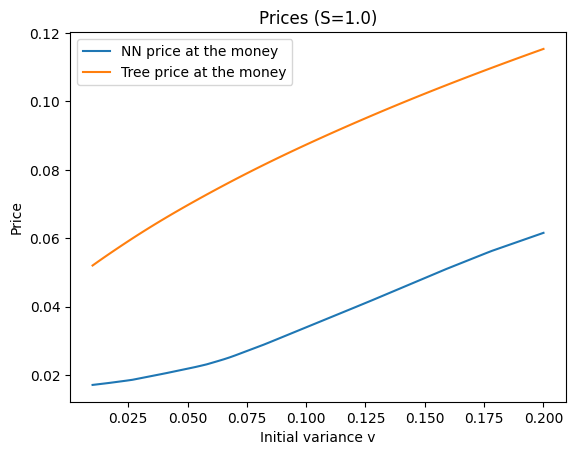

In [11]:
# Relative error at the money

S_ind = 26
# rel_err_atm = np.abs(nn_prices[:, S_ind] - ht_prices[:, S_ind]) / np.maximum(np.abs(ht_prices[:, S_ind]), 1e-4)
# plt.plot(Vs, rel_err_atm, label='Relative error at the money')
plt.plot(Vs, nn_prices[:, S_ind], label='NN price at the money')
plt.plot(Vs, ht_prices[:, S_ind], label='Tree price at the money')
plt.xlabel('Initial variance v')
plt.ylabel('Price')
# plt.ylabel('Relative error')
plt.title(f'Prices (S={Ss[S_ind]:.1f})')
plt.legend()
plt.show()

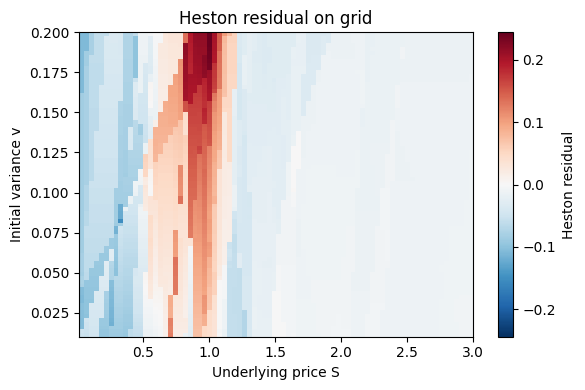

In [12]:
residuals = np.zeros((num_V, num_S))

for i, v_val in enumerate(Vs):
    for j, s_val in enumerate(Ss):
        res = heston_residual(heston_trainer.model, torch.tensor([t], dtype=torch.float32),
                              torch.tensor([s_val], dtype=torch.float32), torch.tensor([v_val], dtype=torch.float32),
                              r=r, kappa=kappa, theta=theta, sigma=sigma, rho=rho)
        residuals[i, j] = res.item() if hasattr(res, "item") else float(res)

plt.figure(figsize=(6, 4))
vmax = np.abs(residuals).max()
vmin = -vmax
im_res = plt.imshow(residuals, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                    aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im_res, label='Heston residual')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Heston residual on grid')
plt.tight_layout()
plt.show()

## Random tree experiments for V_max

In [13]:
# Heston Tree
n = 100
mv = 3 * n
mz = 6 * n

max_multi = 300

tree2 = HestonTreeFast(n=100, mz=mz, mv=mv, K=K, T=T, r=r, kappa=kappa, theta=theta, sigma=sigma, rho=rho)
tree2.build_tree(V_max*(max_multi-1), V_max*(max_multi+1), 0.01, S_max, option_type=option_type, exercise_type=exercise_type)

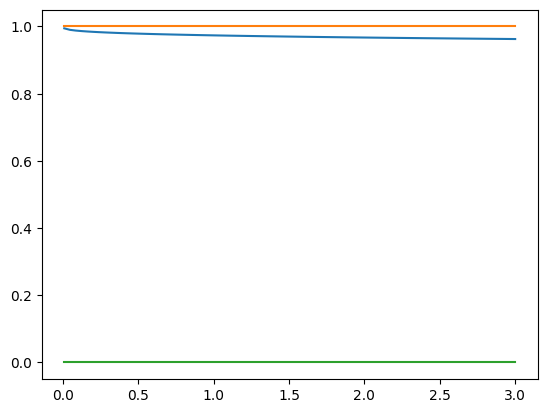

In [14]:
ht_prices_2 = tree2.price(V_max * max_multi, Ss)
plt.plot(Ss, ht_prices_2, label='Tree prices (refined)')
plt.plot(Ss, np.ones_like(Ss) * K, label='Strike price')
plt.plot(Ss, np.zeros_like(Ss), label='Zero line')
plt.show()